<a href="https://colab.research.google.com/github/vaibhav12686/Hybrid-Recommender-System/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub --upgrade

In [3]:
import os
os.environ['DISABLE_COLAB_CACHE'] = 'true'

In [4]:
import kagglehub

path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

print("Path to dataset files:", path)

100%|██████████| 639M/639M [00:08<00:00, 81.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1


In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
data_path = Path("/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1")

In [7]:
songs_data_path = data_path / "Music Info.csv"
users_data_path = data_path / "User Listening  History.csv"

In [55]:
from pathlib import Path

# See everything that was downloaded
for p in data_path.rglob("*"):
    print(p)

/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/User Listening History.csv
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/Music Info.csv
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/World
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/Folk
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/Jazz
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/RnB
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/New Age
/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1/MP3-Example/Electronic
/root/.

In [56]:
users_data_path = list(data_path.rglob("*.csv"))[0]

df_users = pd.read_csv(users_data_path)
df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [8]:
df_songs = pd.read_csv(songs_data_path)
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [9]:
df_songs.shape

(50683, 21)

In [10]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

In [11]:
column_drop = ["spotify_preview_url"]

df_songs.drop(columns=column_drop, inplace=True)

df_songs.head()

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [12]:
# check missing values

df_songs.isna().sum()

,0
track_id,0
name,0
artist,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0
energy,0


In [13]:
!pip install missingno

import missingno as msno

<Axes: >

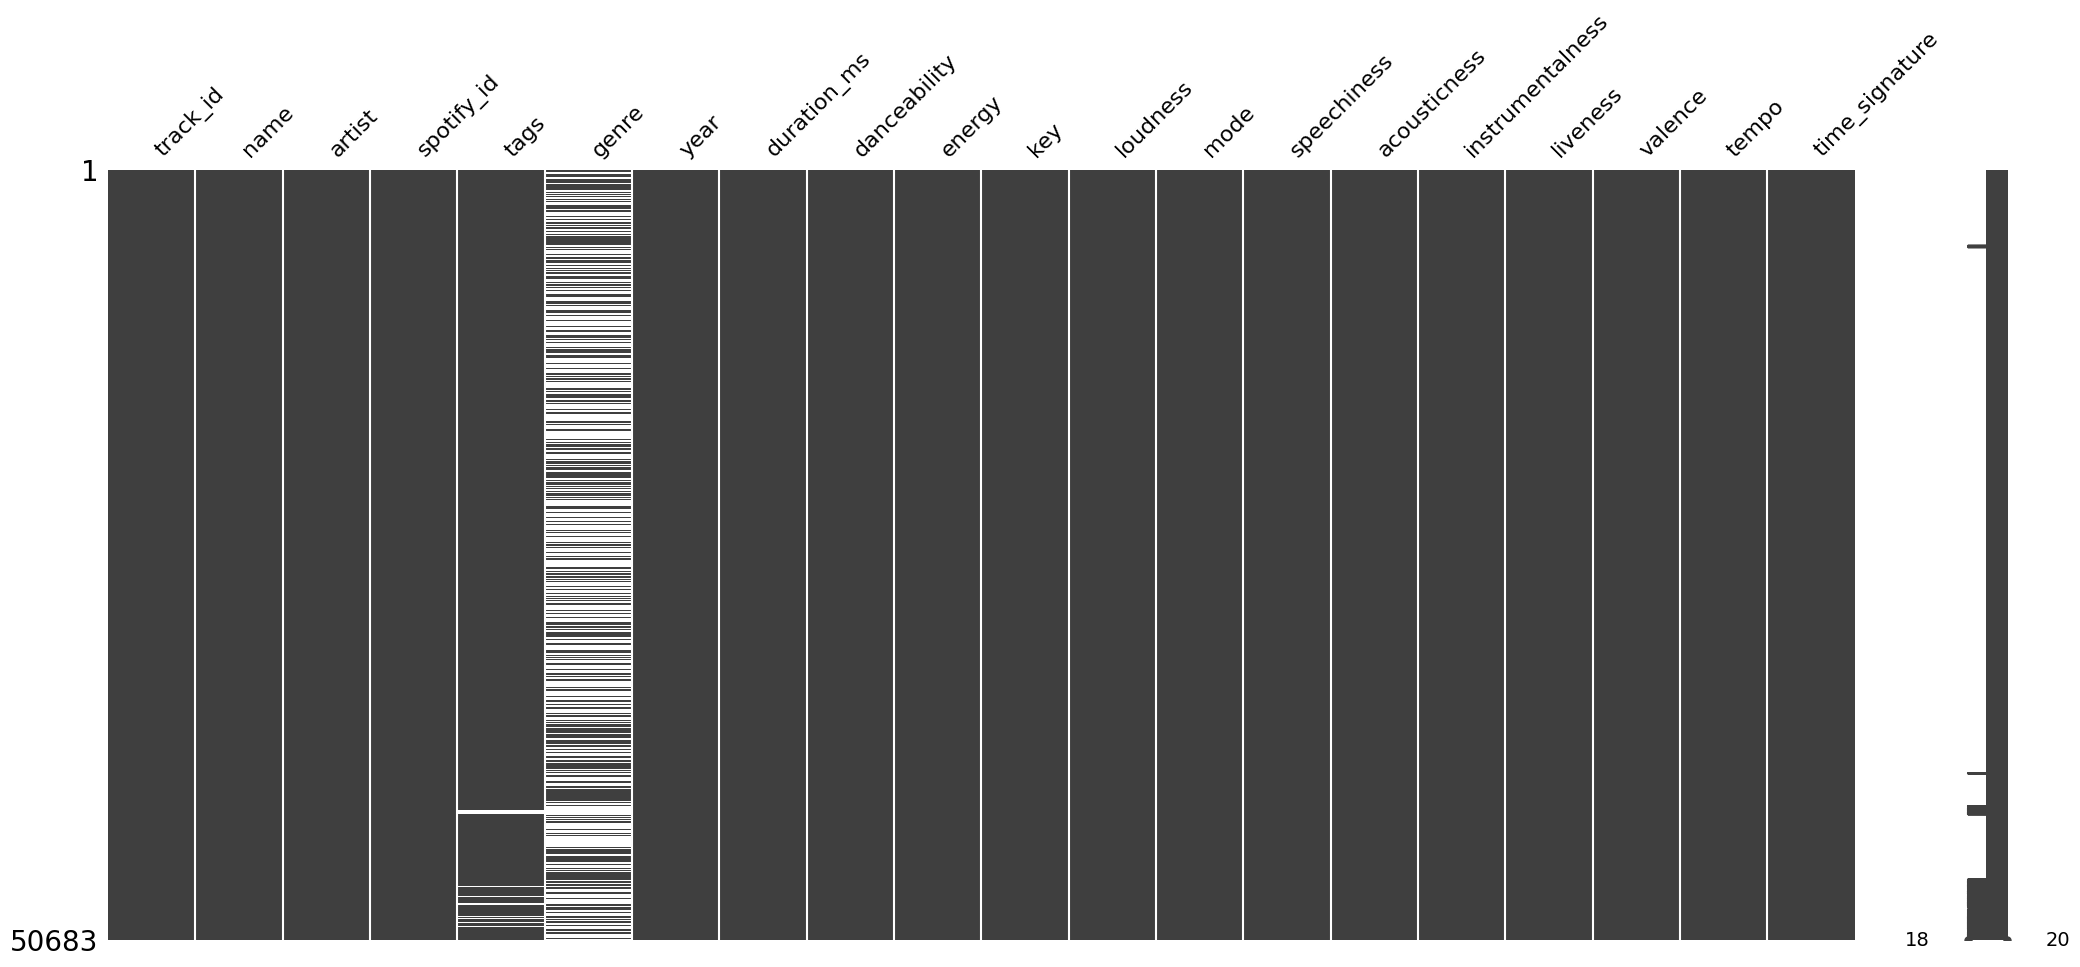

In [14]:
msno.matrix(df_songs)

In [15]:
# ratio of missing values in data

(df_songs.isna().mean().sort_values(ascending=False).head(2).mul(100))

,0
genre,55.906320
tags,2.223625


In [16]:
# duplicates in data based on names of song

int(df_songs.assign(name=df_songs['name'].str.lower())
 .duplicated(subset='name')
 .sum())

815

In [17]:
# rows that are duplicate

(
    df_songs
    .loc[
        df_songs
        .assign(name=df_songs['name'].str.lower())
        .duplicated(subset='name',keep=False)
    ]
    .assign(name=df_songs['name'].str.lower())
    .sort_values("name")
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
34480,TRKKZMK128F4257579,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,0.840,0,-6.038,0,0.0390,0.152000,0.005970,0.107,0.441,78.009,4
6588,TRGGALK12903CB68E5,3 am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, pop, alternative_rock, 90s,...",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
29795,TRLOXMF128F934BF04,3am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, 90s, piano, american, pop_rock",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
43800,TRPWOAS128E0781045,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,0.871,0,-4.604,0,0.0795,0.009060,0.000000,0.579,0.538,189.760,4
15088,TRJRBRX128F4255789,4th of july,Soundgarden,237oH9rNUYpIBeHfAn3WJ0,"hard_rock, 90s, grunge",NaN,1994,308866,0.368,0.749,5,-5.523,0,0.0392,0.109000,0.000372,0.175,0.193,141.901,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34772,TRJFGYO128F4259743,you're the one that i want,Lo-Fang,1dEHQktvcM8vCCyI1x7yVB,"indie, male_vocalists, cover",NaN,2014,204706,0.445,0.309,11,-12.517,0,0.0404,0.643000,0.000369,0.224,0.153,119.754,4
32677,TRFZYLL128F146902A,you've really got a hold on me,Smokey Robinson and The Miracles,03AkIZeRvGpTvDF9vNJtdj,"soul, 60s, oldies",Rock,2012,179513,0.674,0.515,0,-6.895,1,0.0296,0.724000,0.000000,0.339,0.596,116.678,3
20976,TRUXHGS128F145E41A,you've really got a hold on me,The Miracles,01FtGX94CSvO5Zxs5B6AMM,"soul, 60s, oldies",NaN,1994,180266,0.679,0.406,0,-10.533,1,0.0312,0.755000,0.000000,0.412,0.511,117.940,3
27680,TRXWPMW12903CB42A0,zombies,Childish Gambino,73kAUSAht4YOR7xNPmNb2L,funk,NaN,2016,281813,0.653,0.411,0,-11.986,1,0.1270,0.503000,0.000969,0.067,0.468,160.055,4


In [18]:
# drop duplicates

df_songs.drop_duplicates(subset=["spotify_id","year","duration_ms"],inplace=True)

In [19]:
# check for duplicates

(
    df_songs
    .duplicated(subset=["spotify_id","year","duration_ms"])
    .sum()
)

np.int64(0)

# ***Column Wise Analysis***

In [22]:
# list of columns in data

df_songs.columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [23]:
df_songs.dtypes

,0
track_id,object
name,object
artist,object
spotify_id,object
tags,object
genre,object
year,int64
duration_ms,int64
danceability,float64
energy,float64


In [24]:
df_songs.shape

(50674, 20)

In [25]:
# Categorical Columns

categorical_features = df_songs.select_dtypes(include="object").columns
categorical_features

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre'], dtype='object')

In [26]:
def categorical_analysis(df,feature_names,k_artists=15):
    for feature in feature_names:
        print(f"Number of categories in column {feature} are ",df[feature].str.lower().nunique())

        if feature in ["artist","genre"]:
            print(df[feature].value_counts().head(k_artists))

        if feature == "genre":
            print(f"The unique categories in {feature} column are: ", df[feature].dropna().unique())
        print("#" * 75)

In [27]:
# perform catagorical analysis

categorical_analysis(df_songs,categorical_features)

Number of categories in column track_id are  50674
###########################################################################
Number of categories in column name are  49860
###########################################################################
Number of categories in column artist are  8317
artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
In Flames              76
Elliott Smith          76
Mogwai                 75
Boards of Canada       75
Name: count, dtype: int64
###########################################################################
Number of categories in column spotify_id are  50674
###########################################################################
Number of categories in column tags are  20054
###########################

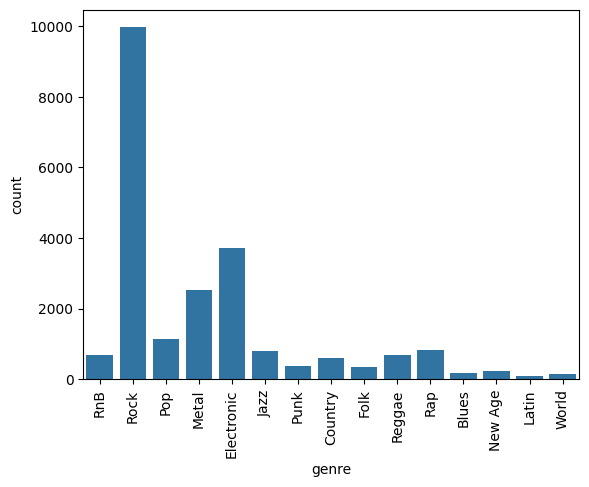

In [28]:
# countplot of genre

sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

In [29]:
# genre group

genre_group = df_songs.groupby("genre")

genre_group[['genre','tags']].sample(3)

,genre,tags
43642,Blues,j_pop
44395,Blues,"blues, blues_rock"
23948,Blues,"blues, guitar, blues_rock"
33807,Country,country
33886,Country,country
33460,Country,country
43232,Electronic,"death_metal, grindcore"
11335,Electronic,"electronic, ambient, experimental, instrumenta..."
27003,Electronic,"electronic, ambient, german, downtempo"
34842,Folk,"folk, acoustic, male_vocalists"


In [30]:
# song titles in the data that are not in english

(df_songs
    .loc[
        df_songs
        .loc[:,"name"]
        .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")
    ]
)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8692/2111686342.py:7: SyntaxWarning: invalid escape sequence '\d'
  .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")


,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2455,TRBGIZH128F4252D9E,2 + 2 = 5,Radiohead,0dUSgj5UiJHY92RCuEFYcx,"rock, electronic, alternative, indie, alternat...",Rock,2008,199360,0.443,0.717,5,-5.498,0,0.0504,0.182000,0.000051,0.3450,0.3860,149.582,4
4463,TRGHMRU128F1478067,"I Put The ""Metro"" In Metronome",Cute Is What We Aim For,718VxOgHaLU7oGS9686hg6,"alternative, emo",Rock,2006,206053,0.538,0.858,11,-3.862,1,0.0638,0.085200,0.000000,0.2580,0.7060,149.971,4
6870,TRGIILN12903CE46BB,1+1,Beyoncé,0b4bcwV5QWTzgza5u1gh5C,"female_vocalists, soul, rnb, beautiful",NaN,2011,273880,0.303,0.384,6,-7.342,1,0.0339,0.381000,0.000005,0.0661,0.2610,63.345,5
7902,TRZMLSV128F9305C8C,B********,Rammstein,2fKyVXrtvFkqv5lVPf1UXa,"metal, industrial, german",Rock,2009,254013,0.352,0.905,9,-3.792,1,0.0836,0.000895,0.218000,0.1810,0.3270,141.016,3
7974,TRFRAEO128F4279C87,F**k the System,System of a Down,0uvPnGOwcaUNT6gwJF98wL,"metal, nu_metal",Metal,2002,132733,0.474,0.994,8,-1.884,1,0.1030,0.002160,0.126000,0.3140,0.8470,171.433,4
10722,TRODWHD128F92FD8BA,4 + 20,"Crosby, Stills, Nash & Young",2jZPEeW2ynykb2GkVqpOkJ,"rock, classic_rock, folk, singer_songwriter, a...",Rock,1970,126640,0.638,0.058,4,-25.243,1,0.0388,0.928000,0.079000,0.1130,0.1260,140.964,4
13127,TRLMIXB128EF3435DD,M+M's,blink-182,0z6VQdAqi0HjQYULMUYpBt,"punk, punk_rock",NaN,2005,155680,0.212,0.921,9,-6.092,1,0.0567,0.000054,0.003990,0.0669,0.6800,159.629,4
14454,TRKEIVB128F930A597,"Nuthin' But a ""G"" Thang",Dr. Dre,1qaZx6y94LiMy2KdhHxRTy,"rap, 90s, hip_hop",NaN,2005,230026,0.817,0.704,7,-8.336,1,0.2850,0.009390,0.000000,0.0850,0.6800,94.627,4
17862,TRBZLOG12903CB78FD,I Belong To You [+Mon Coeur S'Ouvre A Ta Voix],Muse,114rzL6VEy9bb3amPcY3tw,"rock, alternative_rock, progressive_rock, soun...",Rock,2009,338813,0.481,0.603,2,-6.590,1,0.0280,0.166000,0.032100,0.1090,0.2130,105.974,4
22541,TRYVOPZ128F4254176,£4,These New Puritans,1LsQ5WkLU8ubiAz6AtMNll,"electronic, alternative, british, industrial, ...",Rock,2008,133173,0.692,0.759,11,-9.216,1,0.0533,0.052200,0.012900,0.4630,0.2560,99.988,4


In [31]:
# artists in the data that are not in english

(df_songs
    .loc[
        df_songs
        .loc[:,"artist"]
        .str.contains("[^\d\w\s.?!':;-_\(\)\{\},\.#-+&\/\-\"]")
    ]
)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8692/839526650.py:7: SyntaxWarning: invalid escape sequence '\d'
  .str.contains("[^\d\w\s.?!':;-_\(\)\{\},\.#-+&\/\-\"]")


,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
25657,TRUOKRP128F9306B97,DAYBREAK'S BELL,L'Arc~en~Ciel,0f6N93Iqa1jIGY87ckKe8h,"japanese, j_pop",NaN,2007,251653,0.442,0.939,7,-4.032,1,0.0432,0.001010,0.000282,0.3040,0.780,156.138,4
25688,TRYYZGB128F9306B92,MY HEART DRAWS A DREAM,L'Arc~en~Ciel,0K1VcVuws8cBEOS8bb8Svo,"japanese, j_pop",NaN,2007,256826,0.449,0.812,2,-4.105,1,0.0332,0.000732,0.000000,0.1130,0.287,131.850,4
25696,TRYAFFS128F425E71A,Seventh Heaven,L'Arc~en~Ciel,0vc0kp9kYeqLCoDOKFYESL,"japanese, j_pop",NaN,2007,301373,0.488,0.963,9,-3.486,1,0.0532,0.000381,0.000000,0.7340,0.795,129.963,4
25704,TRZBUIY128F9306B9D,Hurry Xmas,L'Arc~en~Ciel,0NMWlIwjGldOgbABHTYx82,"japanese, j_pop",Rock,2007,289133,0.447,0.869,0,-3.362,1,0.0508,0.043600,0.000001,0.1350,0.562,116.043,4
25715,TRDLCHM128F427F235,Spirit dreams inside,L'Arc~en~Ciel,0hyTPlLk6MWOGiKFstN0S2,japanese,NaN,2002,224013,0.510,0.959,9,-4.793,1,0.0548,0.000194,0.002000,0.1950,0.693,118.017,4
25763,TRKTCEP128F9306B91,Pretty girl,L'Arc~en~Ciel,0QUESFm42vSLGffjwud4jl,"japanese, j_pop",Rock,2007,197866,0.373,0.954,0,-3.024,1,0.0777,0.001360,0.000000,0.0548,0.695,176.037,4
25788,TRMDISG128EF341CBC,Lover Boy,L'Arc~en~Ciel,69Gd7FRSCuB4X7D7gDOdhz,japanese,NaN,2004,285026,0.428,0.977,4,-4.600,0,0.0701,0.003850,0.001320,0.1630,0.504,152.023,4
25790,TRHNIIF128F42884A7,TRUST,L'Arc~en~Ciel,5ROfpAhDOiDkyn17SNDtAG,japanese,NaN,2005,269066,0.507,0.895,2,-5.892,1,0.0432,0.002160,0.002600,0.0745,0.393,95.965,4
25799,TRMZMPL128F1490F27,Niji,L'Arc~en~Ciel,1AhmwzPwhatp999J4Ky9nH,"japanese, j_pop",NaN,1998,305600,0.521,0.706,2,-6.931,1,0.0284,0.001310,0.000206,0.3610,0.534,93.020,4
25800,TRANWBU128F42717D4,My Dear,L'Arc~en~Ciel,12UBEdmkCBXtnbnQEvdHWp,japanese,NaN,2005,309826,0.464,0.804,8,-5.762,0,0.0320,0.198000,0.006470,0.1360,0.362,112.013,4


In [32]:
df_songs['tags'][0]

'rock, alternative, indie, alternative_rock, indie_rock, 00s'

In [33]:
all_tags = []

for tags in df_songs["tags"].dropna().str.replace(" ","").str.split(","):
    all_tags.extend(tags)

In [34]:
print("The number of unique tags are ",len(set(all_tags)))

The number of unique tags are  100


In [35]:
set(all_tags)

{'00s',
 '60s',
 '70s',
 '80s',
 '90s',
 'acoustic',
 'alternative',
 'alternative_rock',
 'ambient',
 'american',
 'avant_garde',
 'beautiful',
 'black_metal',
 'blues',
 'blues_rock',
 'british',
 'britpop',
 'chill',
 'chillout',
 'classic_rock',
 'classical',
 'country',
 'cover',
 'dance',
 'dark_ambient',
 'death_metal',
 'doom_metal',
 'downtempo',
 'drum_and_bass',
 'electro',
 'electronic',
 'emo',
 'experimental',
 'female_vocalists',
 'folk',
 'french',
 'funk',
 'german',
 'gothic',
 'gothic_metal',
 'grindcore',
 'grunge',
 'guitar',
 'hard_rock',
 'hardcore',
 'heavy_metal',
 'hip_hop',
 'house',
 'idm',
 'indie',
 'indie_pop',
 'indie_rock',
 'industrial',
 'instrumental',
 'j_pop',
 'japanese',
 'jazz',
 'lounge',
 'love',
 'male_vocalists',
 'mellow',
 'melodic_death_metal',
 'metal',
 'metalcore',
 'new_age',
 'new_wave',
 'noise',
 'nu_metal',
 'oldies',
 'piano',
 'polish',
 'pop',
 'pop_rock',
 'post_hardcore',
 'post_punk',
 'post_rock',
 'power_metal',
 'progress

In [36]:
# unique tags in the data

(df_songs
    .loc[:,"tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .unique()
)

array(['rock', 'alternative', 'indie', 'alternative_rock', 'indie_rock',
       '00s', 'pop', 'british', '90s', 'love', 'britpop', 'grunge',
       'piano', 'beautiful', 'mellow', 'chillout', 'funk', 'electronic',
       'dance', 'hip_hop', 'trip_hop', 'metal', 'hard_rock', 'nu_metal',
       'progressive_rock', 'classic_rock', '80s', '70s', 'experimental',
       'soundtrack', 'female_vocalists', 'heavy_metal', 'rap', '60s',
       'post_punk', 'pop_rock', 'punk', 'punk_rock', 'acoustic', 'emo',
       'new_wave', 'chill', 'indie_pop', 'gothic_metal', 'gothic',
       'thrash_metal', 'folk', 'singer_songwriter', 'country', 'cover',
       'blues_rock', 'psychedelic', 'psychedelic_rock', 'guitar',
       'american', 'ska', 'ambient', 'blues', 'oldies', 'french',
       'male_vocalists', 'reggae', 'instrumental', 'jazz', 'avant_garde',
       'industrial', 'german', 'synthpop', 'hardcore', 'metalcore',
       'screamo', 'post_rock', 'swedish', 'doom_metal', 'power_metal',
       'rnb', 

In [37]:
integer_columns = df_songs.select_dtypes(include="int").columns
integer_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [38]:
df_songs[integer_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


In [39]:
# statistical summary

(df_songs
    .loc[:,integer_columns]
    .drop(columns=["duration_ms"])
    .assign(**{
        col: df_songs[col].astype("object")
        for col in integer_columns.drop("duration_ms")
    })
    .describe()
)

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


In [40]:
# range of data

(df_songs
    .loc[:,integer_columns]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns=["duration_ms"])
    .agg(["min","max"])
)

,year,key,mode,time_signature,duration_minutes
min,1900,0,0,0,0.023983
max,2022,11,1,5,63.606217


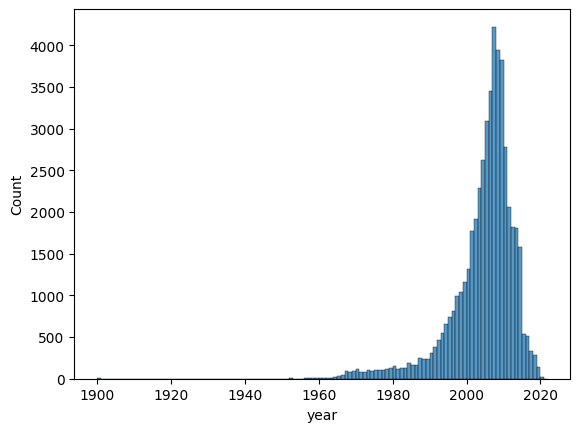

In [41]:
# number of songs per year in data

sns.histplot(df_songs,x="year",bins=df_songs["year"].max() - df_songs["year"].min(),stat="count")
plt.show()

In [42]:
# most songs from which year

(df_songs
    .loc[:,"year"]
    .value_counts()
    .head(5)
    .sort_index()
)

,count
year,
2005,3085
2006,3453
2007,4221
2008,3947
2009,3827


In [43]:
# unique values in the key column

(np.sort(df_songs
            .loc[:,"key"]
            .unique())
)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

<Axes: title={'center': 'Percentage of Songs'}, xlabel='Percentage', ylabel='key'>

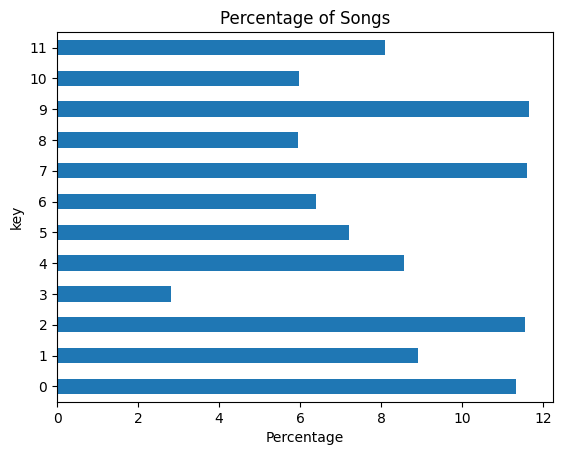

In [44]:
# percentage of songs wrt to key in the data

(df_songs['key']
    .value_counts(normalize=True)
    .mul(100)
    .sort_index()
    .plot(kind='barh',title="Percentage of Songs",xlabel="Percentage")
)

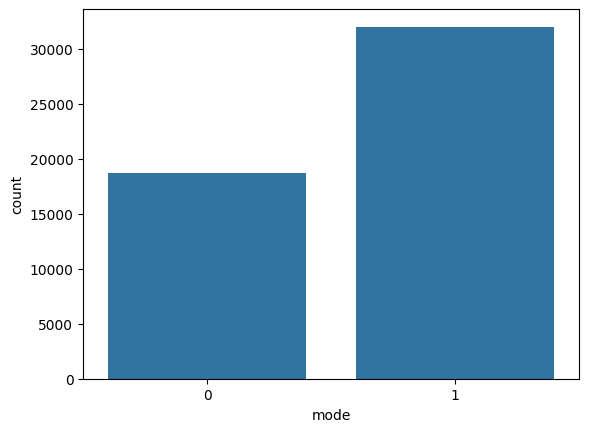

In [45]:
# countplot for mode

sns.countplot(df_songs,x="mode")
plt.show()

In [46]:
# unique values for time signature

(np.sort(df_songs
            .loc[:,"time_signature"]
            .unique())
)

array([0, 1, 3, 4, 5])

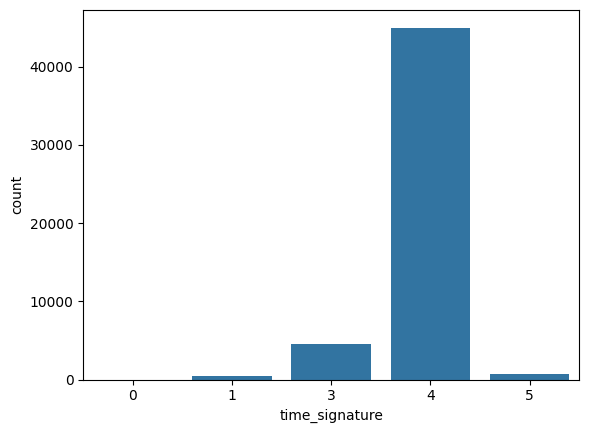

In [47]:
# countplot for time signature

sns.countplot(df_songs,x="time_signature")
plt.show()

In [48]:
(df_songs['time_signature']
    .value_counts(normalize=True)
    .mul(100)
)

,proportion
time_signature,
4,88.765442
3,8.880294
5,1.444528
1,0.890003
0,0.019734


In [49]:
# statistical summary of time duration

(df_songs
    .loc[:,["duration_ms"]]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns="duration_ms")
    .describe()
)

,duration_minutes
count,50674.000000
mean,4.185893
std,1.793154
min,0.023983
25%,3.212217
50%,3.915550
75%,4.803046
max,63.606217


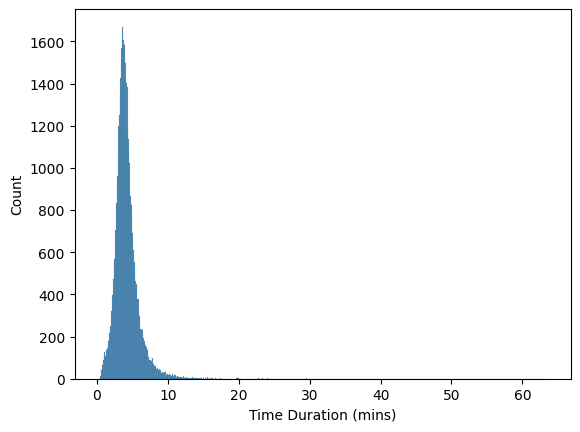

In [50]:
# time duration histogram

time_duration_mins = df_songs["duration_ms"].div(1000).div(60)

sns.histplot(time_duration_mins)
plt.xlabel("Time Duration (mins)")
plt.show()

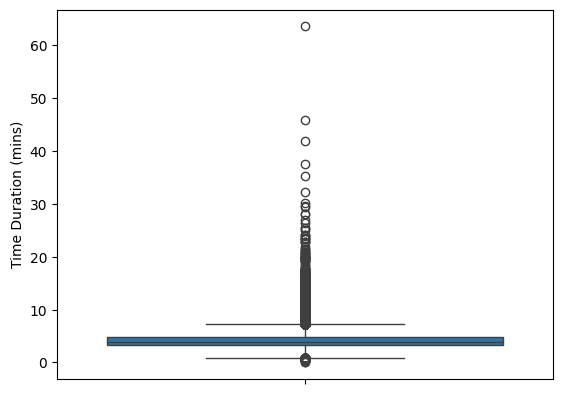

In [51]:
# time duration boxplot

sns.boxplot(time_duration_mins)
plt.ylabel("Time Duration (mins)")
plt.show()

In [52]:
continuous_columns = df_songs.select_dtypes(include="float").columns
continuous_columns

Index(['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo'],
      dtype='object')

In [ ]:
def numerical_analysis(df,columns):
    for column in columns:
        print(f"Numerical Analysis for column {column}")
        print("Statistical Summary")
        print(df[column].describe())

        fig = plt.figure(figsize=(12,4))
        # hitogram for column
        plt.subplot(1,2,1)
        sns.histplot(df[column])
        plt.title(f"Histogram for {column}")
        # boxplot for column
        plt.subplot(1,2,2)
        sns.boxplot(df[column])
        plt.title(f"Boxplot for {column}")
        plt.show()

        print("#" * 120)
    print("*" * 120)
    print("Pairplot")
    sns.pairplot(df[columns])
    plt.show()

Numerical Analysis for column danceability
Statistical Summary
count    50674.000000
mean         0.493522
std          0.178833
min          0.000000
25%          0.364000
50%          0.497000
75%          0.621000
max          0.986000
Name: danceability, dtype: float64


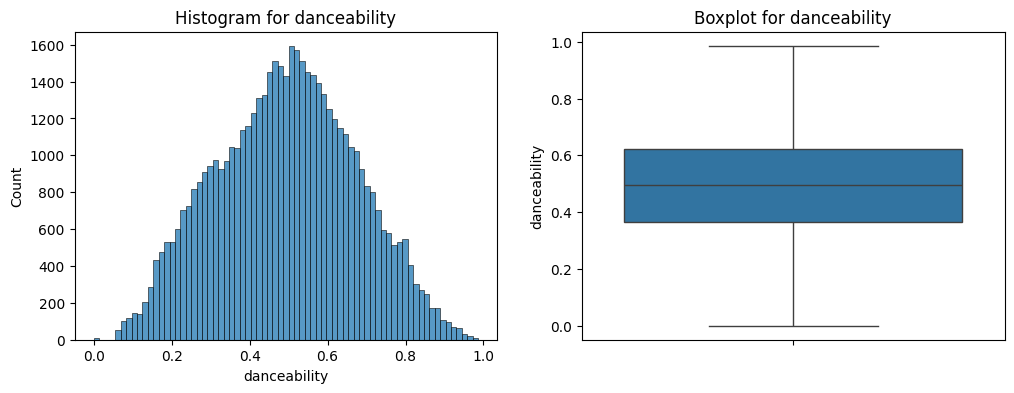

########################################################################################################################
Numerical Analysis for column energy
Statistical Summary
count    50674.000000
mean         0.686507
std          0.251803
min          0.000000
25%          0.514000
50%          0.744000
75%          0.905000
max          1.000000
Name: energy, dtype: float64


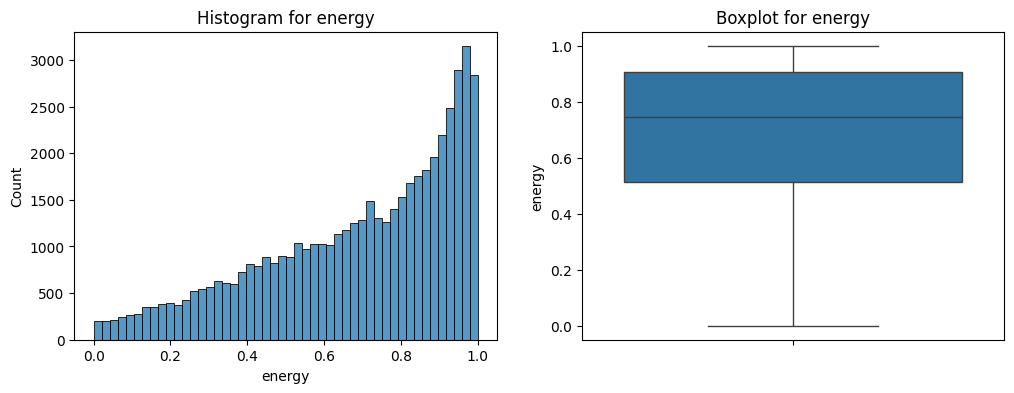

########################################################################################################################
Numerical Analysis for column loudness
Statistical Summary
count    50674.000000
mean        -8.291007
std          4.548359
min        -60.000000
25%        -10.375000
50%         -7.199500
75%         -5.089000
max          3.642000
Name: loudness, dtype: float64


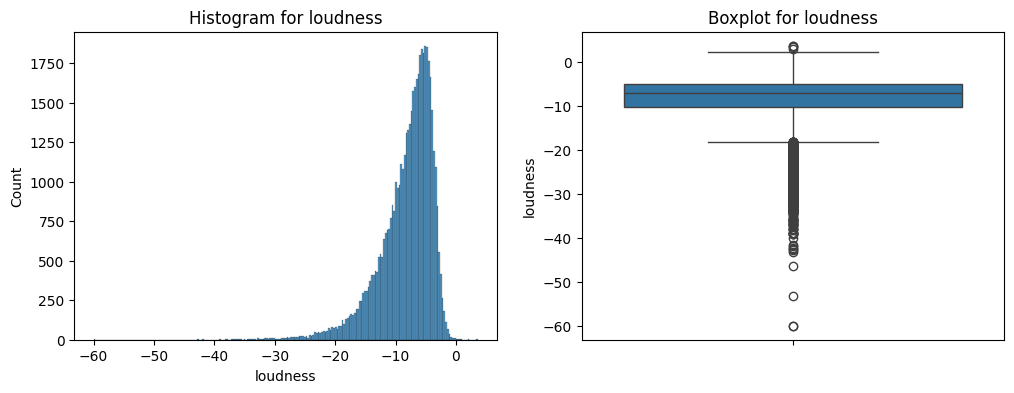

########################################################################################################################
Numerical Analysis for column speechiness
Statistical Summary
count    50674.000000
mean         0.076026
std          0.076012
min          0.000000
25%          0.035200
50%          0.048200
75%          0.083500
max          0.954000
Name: speechiness, dtype: float64


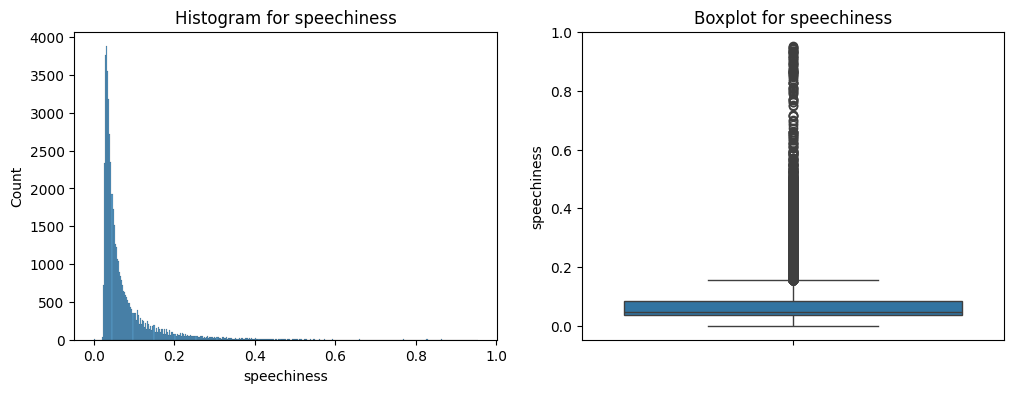

########################################################################################################################
Numerical Analysis for column acousticness
Statistical Summary
count    50674.000000
mean         0.213798
std          0.302839
min          0.000000
25%          0.001400
50%          0.039900
75%          0.340000
max          0.996000
Name: acousticness, dtype: float64


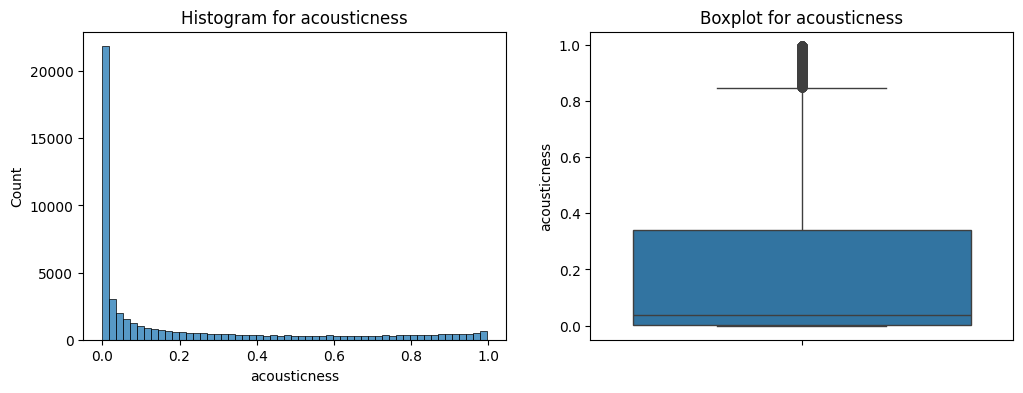

########################################################################################################################
Numerical Analysis for column instrumentalness
Statistical Summary
count    50674.000000
mean         0.225299
std          0.337067
min          0.000000
25%          0.000018
50%          0.005630
75%          0.441000
max          0.999000
Name: instrumentalness, dtype: float64


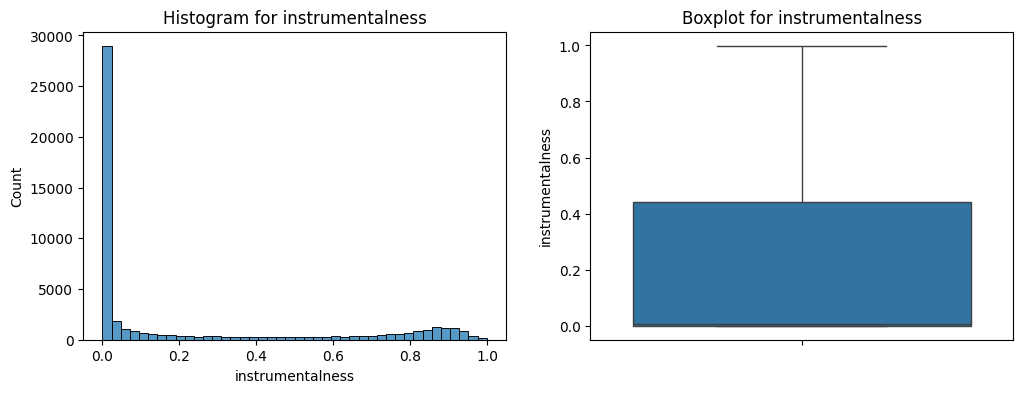

########################################################################################################################
Numerical Analysis for column liveness
Statistical Summary
count    50674.000000
mean         0.215439
std          0.184708
min          0.000000
25%          0.098400
50%          0.138000
75%          0.289000
max          0.999000
Name: liveness, dtype: float64


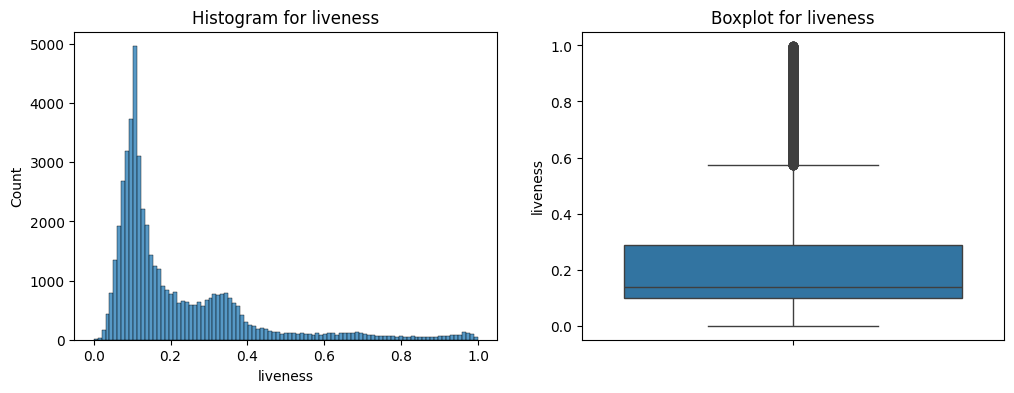

########################################################################################################################
Numerical Analysis for column valence
Statistical Summary
count    50674.000000
mean         0.433113
std          0.258767
min          0.000000
25%          0.214000
50%          0.405000
75%          0.634000
max          0.993000
Name: valence, dtype: float64


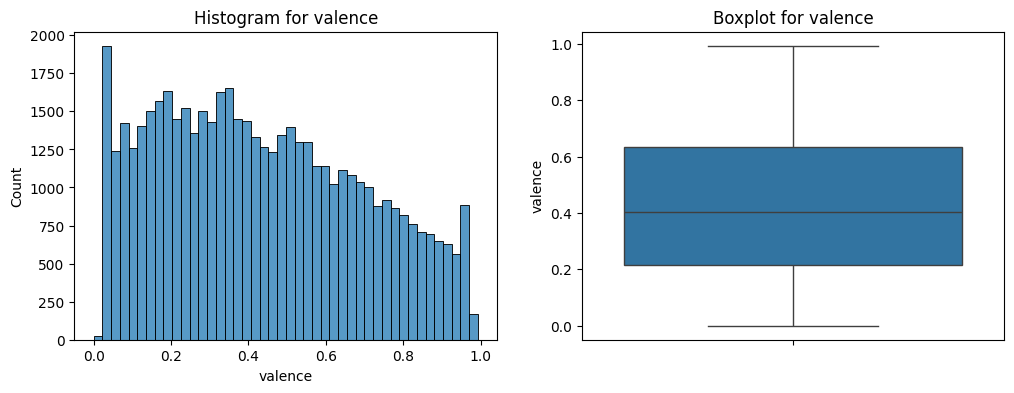

########################################################################################################################
Numerical Analysis for column tempo
Statistical Summary
count    50674.000000
mean       123.508794
std         29.622349
min          0.000000
25%        100.682500
50%        121.989000
75%        141.642250
max        238.895000
Name: tempo, dtype: float64


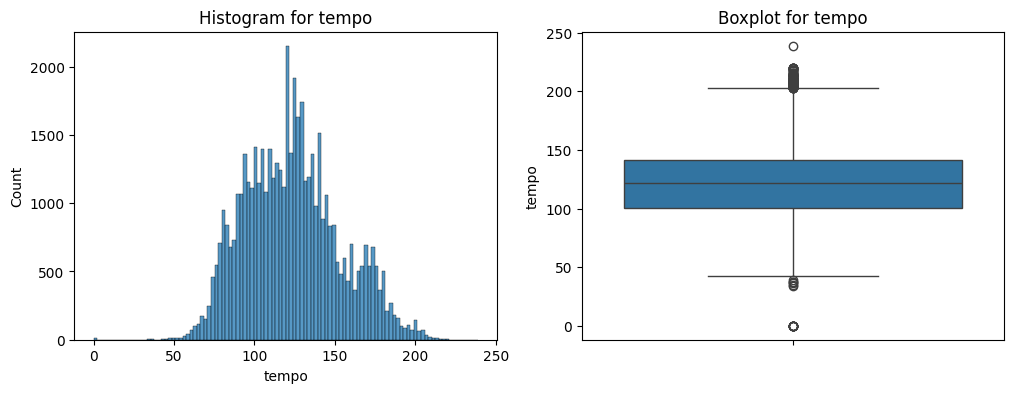

########################################################################################################################
************************************************************************************************************************
Pairplot


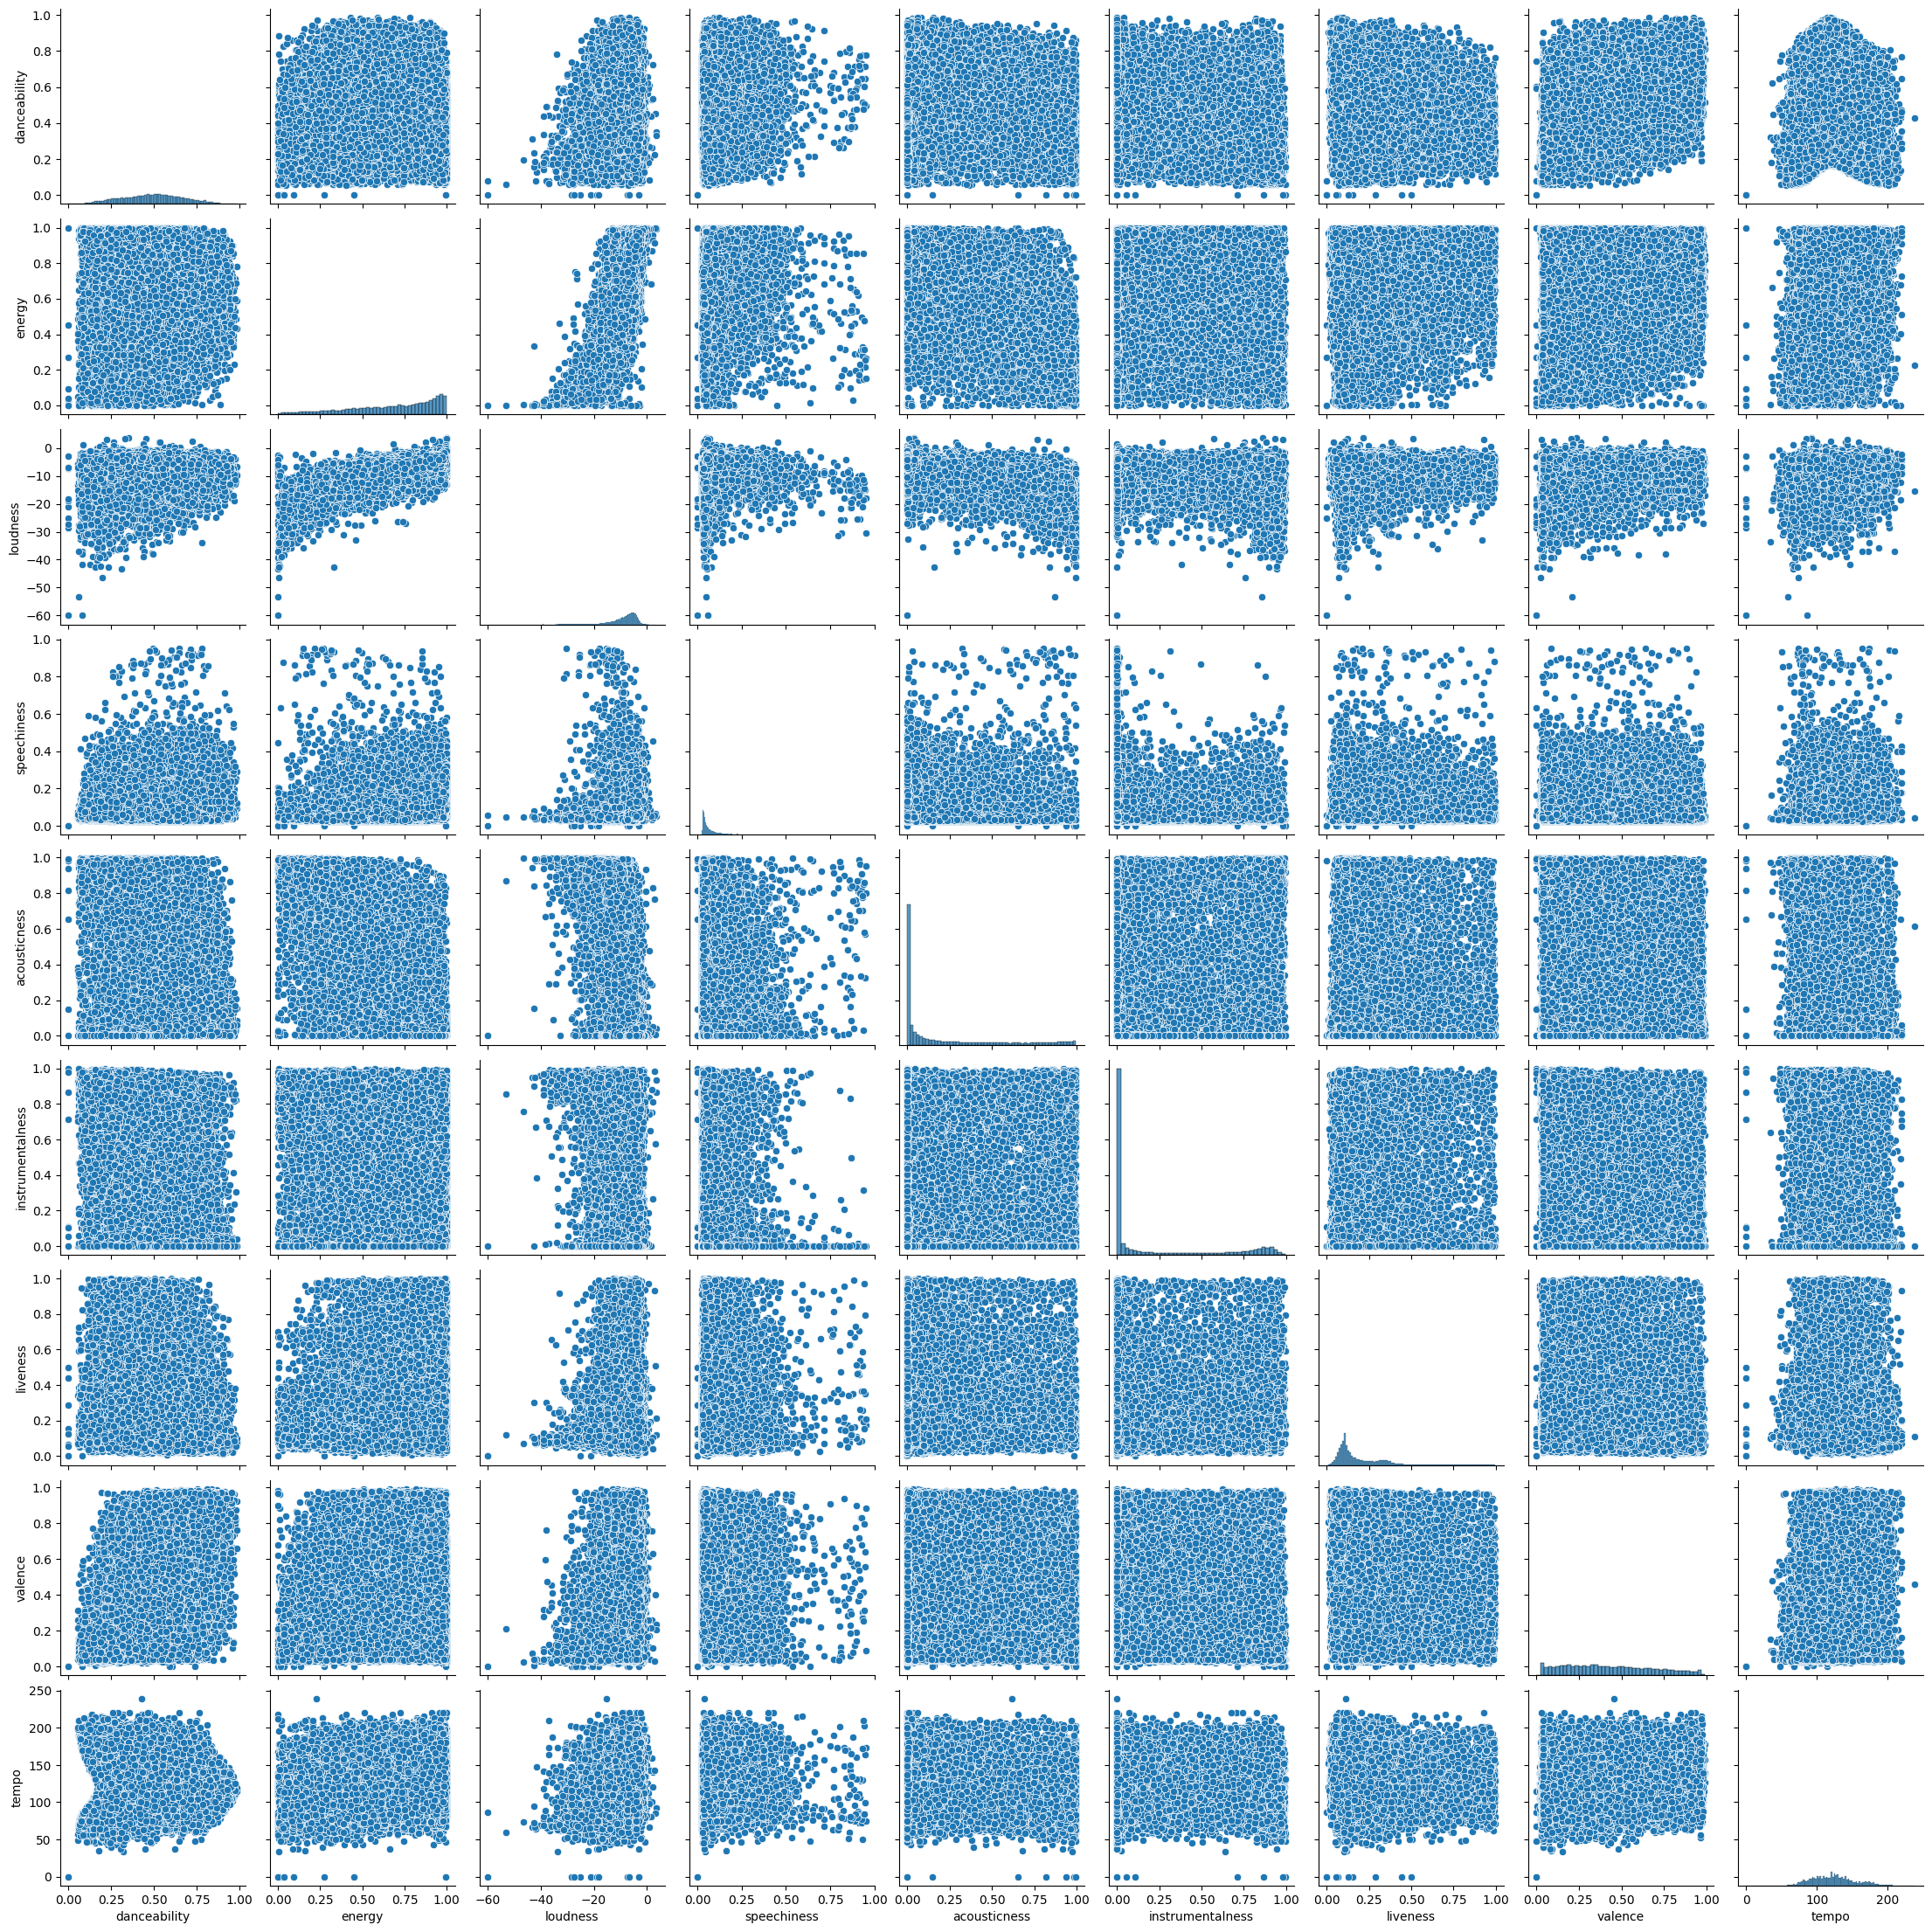

In [ ]:
numerical_analysis(df_songs,continuous_columns)

In [57]:
df_users = pd.read_csv(users_data_path)

df_users.head()

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


In [58]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   track_id   object
 1   user_id    object
 2   playcount  int64 
dtypes: int64(1), object(2)
memory usage: 222.3+ MB


In [59]:
df_users.duplicated(subset=["track_id","user_id"]).sum()

np.int64(0)

In [60]:
# check for missing values

df_users.isna().sum()

,0
track_id,0
user_id,0
playcount,0


In [61]:
# unqiue users in the data

(df_users
    .loc[:,"user_id"]
    .nunique()
)

962037

In [62]:
# unique songs in the data

(df_users
    .loc[:,"track_id"]
    .nunique()
)

30459

In [63]:
top_10_songs = (
    df_users
    .loc[:,"track_id"]
    .value_counts()
    .head(10)
)

top_10_songs

,count
track_id,
TRONYHY128F92C9D11,80656
TRUFTBY128F93450B8,39529
TRXWAZC128F9314B3E,30873
TRCPXID128F92D5D3C,30057
TRGCHLH12903CB7352,29708
TROMKCG128F9320C09,28735
TRPFYYL128F92F7144,28412
TRPGPDK12903CCC651,27276
TRWAQOC12903CB84CA,27222


In [65]:
(
    df_songs
    .loc[df_songs["track_id"].isin(top_10_songs.index.tolist()),:]
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
44,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,0jLnevC3Vn34qVWrAa4X6x,"rock, alternative, indie, pop, alternative_roc...",NaN,1999,358333,0.383,0.907,9,-5.409,1,0.0405,0.031300,0.000000,0.3470,0.514,171.052,4
59,TRPFYYL128F92F7144,Float On,Modest Mouse,1Urf1M52P3R6NYdAOJizoW,"rock, alternative, indie, alternative_rock, in...",Rock,2004,208466,0.646,0.893,6,-4.799,1,0.0301,0.015100,0.000004,0.0892,0.559,100.951,4
323,TRONYHY128F92C9D11,Revelry,Kings of Leon,039Q3UlFQ6kavVIZHpO4mL,"rock, alternative, indie, alternative_rock, in...",Rock,2008,201733,0.437,0.748,4,-6.593,1,0.0689,0.196000,0.000328,0.1580,0.383,149.834,4
1876,TRXWAZC128F9314B3E,Heartbreak Warfare,John Mayer,0naTARZScsZOtx3nlhlq0Y,"rock, alternative, indie, pop, singer_songwrit...",Rock,2010,263280,0.626,0.572,2,-7.989,1,0.0228,0.197000,0.000497,0.2720,0.297,97.081,4
2107,TRUFTBY128F93450B8,Alejandro,Lady Gaga,0CXHrBetrvDx4PwBar1ZWj,"electronic, pop, female_vocalists, dance",Pop,2010,274800,0.626,0.800,11,-6.777,0,0.0435,0.000582,0.001140,0.3740,0.353,98.995,4
2742,TRCPXID128F92D5D3C,Halo,Depeche Mode,0Ti7ZxvgWq74Ls56vYP3Ov,"electronic, pop, 80s, british, 90s, new_wave, ...",NaN,1990,270160,0.672,0.508,3,-12.620,0,0.0310,0.052800,0.067100,0.0801,0.741,112.184,4
3168,TRWAQOC12903CB84CA,Sexy Bitch,David Guetta,01N6xy2PX9fKVfrA2YOkYd,"electronic, dance, house",NaN,2009,193800,0.810,0.595,11,-5.812,0,0.0579,0.067300,0.000764,0.1190,0.813,130.018,4
19724,TROMKCG128F9320C09,Uprising,Sabaton,09tHVoXbJNZUotndn8pfJr,"metal, heavy_metal, power_metal",NaN,2010,295640,0.527,0.866,6,-3.763,0,0.0346,0.009910,0.000052,0.1290,0.428,87.986,4
22071,TRPGPDK12903CCC651,Bring Me To Life,Katherine Jenkins,0rJ8HF2zsxsWMzirj3YFQR,"classical, cover, new_age",Rock,2012,226093,0.429,0.563,4,-8.006,0,0.0300,0.881000,0.000097,0.0760,0.298,95.989,4
23220,TRGCHLH12903CB7352,Party In The U.S.A.,The Barden Bellas,0bz2Uy1KE7bNGsGQU9pZrU,"soundtrack, cover",Pop,2012,63080,0.531,0.360,10,-8.575,0,0.1080,0.822000,0.000000,0.1780,0.701,97.200,4


In [66]:
# most playcounts for songs

top_10_played_songs = (
    df_users.groupby("track_id")['playcount']
    .agg("sum")
    .sort_values(ascending=False)
    .head(10)
)

top_10_played_songs


,playcount
track_id,
TRONYHY128F92C9D11,527893
TRUFTBY128F93450B8,111615
TRZNAHL128F9327D5A,111596
TRCPXID128F92D5D3C,91461
TRPGPDK12903CCC651,91448
TRXWAZC128F9314B3E,87745
TROMKCG128F9320C09,87050
TRPFYYL128F92F7144,85079
TRGCHLH12903CB7352,78443


In [67]:
(
    df_songs
    .loc[df_songs["track_id"].isin(top_10_played_songs.index.tolist()),:]
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
44,TRAALAH128E078234A,Bitter Sweet Symphony,The Verve,0jLnevC3Vn34qVWrAa4X6x,"rock, alternative, indie, pop, alternative_roc...",NaN,1999,358333,0.383,0.907,9,-5.409,1,0.0405,0.031300,0.000000,0.3470,0.5140,171.052,4
59,TRPFYYL128F92F7144,Float On,Modest Mouse,1Urf1M52P3R6NYdAOJizoW,"rock, alternative, indie, alternative_rock, in...",Rock,2004,208466,0.646,0.893,6,-4.799,1,0.0301,0.015100,0.000004,0.0892,0.5590,100.951,4
323,TRONYHY128F92C9D11,Revelry,Kings of Leon,039Q3UlFQ6kavVIZHpO4mL,"rock, alternative, indie, alternative_rock, in...",Rock,2008,201733,0.437,0.748,4,-6.593,1,0.0689,0.196000,0.000328,0.1580,0.3830,149.834,4
1876,TRXWAZC128F9314B3E,Heartbreak Warfare,John Mayer,0naTARZScsZOtx3nlhlq0Y,"rock, alternative, indie, pop, singer_songwrit...",Rock,2010,263280,0.626,0.572,2,-7.989,1,0.0228,0.197000,0.000497,0.2720,0.2970,97.081,4
2107,TRUFTBY128F93450B8,Alejandro,Lady Gaga,0CXHrBetrvDx4PwBar1ZWj,"electronic, pop, female_vocalists, dance",Pop,2010,274800,0.626,0.800,11,-6.777,0,0.0435,0.000582,0.001140,0.3740,0.3530,98.995,4
2742,TRCPXID128F92D5D3C,Halo,Depeche Mode,0Ti7ZxvgWq74Ls56vYP3Ov,"electronic, pop, 80s, british, 90s, new_wave, ...",NaN,1990,270160,0.672,0.508,3,-12.620,0,0.0310,0.052800,0.067100,0.0801,0.7410,112.184,4
19724,TROMKCG128F9320C09,Uprising,Sabaton,09tHVoXbJNZUotndn8pfJr,"metal, heavy_metal, power_metal",NaN,2010,295640,0.527,0.866,6,-3.763,0,0.0346,0.009910,0.000052,0.1290,0.4280,87.986,4
22071,TRPGPDK12903CCC651,Bring Me To Life,Katherine Jenkins,0rJ8HF2zsxsWMzirj3YFQR,"classical, cover, new_age",Rock,2012,226093,0.429,0.563,4,-8.006,0,0.0300,0.881000,0.000097,0.0760,0.2980,95.989,4
23220,TRGCHLH12903CB7352,Party In The U.S.A.,The Barden Bellas,0bz2Uy1KE7bNGsGQU9pZrU,"soundtrack, cover",Pop,2012,63080,0.531,0.360,10,-8.575,0,0.1080,0.822000,0.000000,0.1780,0.7010,97.200,4
25264,TRZNAHL128F9327D5A,Gears,Miss May I,3YC9z1sMjAxn5noHpBLBXd,"metalcore, post_hardcore, screamo",NaN,2010,241466,0.470,0.975,5,-4.479,1,0.1360,0.000027,0.000187,0.1430,0.0796,123.022,4


In [68]:
pd.concat([top_10_songs,top_10_played_songs],axis=1)

,count,playcount
track_id,,
TRONYHY128F92C9D11,80656.0,527893.0
TRUFTBY128F93450B8,39529.0,111615.0
TRXWAZC128F9314B3E,30873.0,87745.0
TRCPXID128F92D5D3C,30057.0,91461.0
TRGCHLH12903CB7352,29708.0,78443.0
TROMKCG128F9320C09,28735.0,87050.0
TRPFYYL128F92F7144,28412.0,85079.0
TRPGPDK12903CCC651,27276.0,91448.0
TRWAQOC12903CB84CA,27222.0,NaN


In [69]:
# most diverse users
# top 10


most_diverse_users = (
                        df_users.groupby("user_id")['track_id']
                        .agg("count")
                        .sort_values(ascending=False)
                        .head(10)
                    )

most_diverse_users

,track_id
user_id,
ec6dfcf19485cb011e0b22637075037aae34cf26,784
4e11f45d732f4861772b2906f81a7d384552ad12,384
726da71c2c2ea119119a7957517fccd028d1be76,376
113255a012b2affeab62607563d03fbdf31b08e7,367
7adec7f006cb09482d36609d205293d8b61f030e,366
fef771ab021c200187a419f5e55311390f850a50,363
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc,362
b4c94d72b15d3c311c10045a58b31f95d9d12785,357
96f7b4f800cafef33eae71a6bc44f7139f63cd7a,356


In [70]:
# most playcounts for users
# top 10

most_active_users = (
                        df_users.groupby("user_id")['playcount']
                        .agg("sum")
                        .sort_values(ascending=False)
                        .head(10)
                    )

most_active_users

,playcount
user_id,
1854daf178674bbac9a8ed3d481f95b76676b414,2953
944cdf52364f45b0edd1c972b5a73d3a86b09c6a,2046
6a8a142084a4818c0dcac48bdfb3c39deacf5168,1942
93158e3983ffc8945e25c793d93d6b67d46cae9d,1845
f0b5c784daaa3c7d50acbb3723c7dd649db2b231,1841
6a58f480d522814c087fd3f8c77b3f32bb161f9d,1783
49127655d27dabab3f469bcdd996330fe4f3e210,1743
3fa44653315697f42410a30cb766a4eb102080bb,1639
839223f11c98e0c8017e8ecd6fc7b8706658c966,1608


In [71]:
pd.concat([most_diverse_users,most_active_users],axis=1)

,track_id,playcount
user_id,,
ec6dfcf19485cb011e0b22637075037aae34cf26,784.0,NaN
4e11f45d732f4861772b2906f81a7d384552ad12,384.0,NaN
726da71c2c2ea119119a7957517fccd028d1be76,376.0,NaN
113255a012b2affeab62607563d03fbdf31b08e7,367.0,NaN
7adec7f006cb09482d36609d205293d8b61f030e,366.0,NaN
fef771ab021c200187a419f5e55311390f850a50,363.0,NaN
8cb51abc6bf8ea29341cb070fe1e1af5e4c3ffcc,362.0,NaN
b4c94d72b15d3c311c10045a58b31f95d9d12785,357.0,NaN
96f7b4f800cafef33eae71a6bc44f7139f63cd7a,356.0,NaN
